In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Research Question:
Can we predict a film's global box office gross?

We plan to have two approaches for this project. Our main focus and approach is to use features that do not contain information on domestic or opening weekend grosses. We want to use features like budget, ratings, and runtime to predict the success a film will have. This is because, in the real world, stakeholders do not have access to this information (US & Canada Gross, Opening Weekend Gross) prior to the film's release.

Our second approach consists of using all features, besides global gross, to predict the global gross. There are cases where films are released domestically prior to being released globally. Some films have information on opening weekend gross or domestic gross, and then get pushed out globally. Not all films have global premiers.

Production teams or private investors are considered stakeholders in this situation and it can benefit them, to see what a film's gross will be. Production puts a lot of time and money into a film and when a project fails,it was simply not worth their money. 

We use feature engineering and one-hot encoding to make the most of our given features, from our dataset. We then use a random forest regressor for our model and see how close we get with visualization and statistical measures.

In [2]:
movies = pd.read_csv("IMDbMovies-Clean.csv")
movies.head()

,Title,Summary,Director,Writer,Main Genres,Motion Picture Rating,Release Year,Runtime (Minutes),Rating (Out of 10),Number of Ratings (in thousands),Budget (in millions),Gross in US & Canada (in millions),Gross worldwide (in millions),Opening Weekend in US & Canada,Gross Opening Weekend (in millions)
0,Napoleon,An epic that details the checkered rise and fa...,Ridley Scott,David Scarpa,"Action,Adventure,Biography",R,2023.0,158.0,6.7,38.0,NaN,37.514,84.968,11.26.2023,20.639
1,The Hunger Games: The Ballad of Songbirds & Sn...,Coriolanus Snow mentors and develops feelings ...,Francis Lawrence,"Michael Lesslie,Michael Arndt,Suzanne Collins","Action,Adventure,Drama",PG-13,2023.0,157.0,7.2,37.0,100.0,105.043,191.729,11.19.2023,44.607
2,The Killer,"After a fateful near-miss, an assassin battles...",David Fincher,"Andrew Kevin Walker,Luc Jacamon,Alexis Nolent","Action,Adventure,Crime",R,2023.0,118.0,6.8,117.0,NaN,NaN,0.421,NaN,NaN
3,Leo,A 74-year-old lizard named Leo and his turtle ...,"David Wachtenheim,Robert Smigel,Robert Marianetti","Paul Sado,Robert Smigel,Adam Sandler","Animation,Comedy,Family",PG,2023.0,102.0,7.0,10.0,NaN,NaN,NaN,NaN,NaN
4,Thanksgiving,"After a Black Friday riot ends in tragedy, a m...",Eli Roth,"Eli Roth,Jeff Rendell","Horror,Mystery,Thriller",R,2023.0,106.0,7.0,9.1,NaN,25.409,29.667,11.19.2023,10.306


In [3]:
movies.columns.tolist()

['Title',
 'Summary',
 'Director',
 'Writer',
 'Main Genres',
 'Motion Picture Rating',
 'Release Year',
 'Runtime (Minutes)',
 'Rating (Out of 10)',
 'Number of Ratings (in thousands)',
 'Budget (in millions)',
 'Gross in US & Canada (in millions)',
 'Gross worldwide (in millions)',
 'Opening Weekend in US & Canada',
 'Gross Opening Weekend (in millions)']

In [4]:
#Start of proj. 
#Cleaning the data.
movies = movies.drop_duplicates()
movies.columns = movies.columns.str.strip() #getting rid of spaces

#Variable Type Numeric Col. filling missing values with numbers's
num_col = ["Runtime (Minutes)","Budget (in millions)","Gross worldwide (in millions)","Rating (Out of 10)",
        "Number of Ratings (in thousands)", "Gross in US & Canada (in millions)","Gross Opening Weekend (in millions)"]

for col in num_col:
    if col in movies.columns:
        movies[col] = pd.to_numeric(movies[col], errors = "coerce") #"coerce" won't stop the program from running if error encountered.

movies = movies.dropna(subset= ["Gross worldwide (in millions)"])

#now we fill in missing values
for col in num_col:
    if col in movies.columns:
        movies[col] = movies[col].fillna(movies[col].median())

#replacing "nan" values
category_col = movies.select_dtypes(include='object').columns
movies[category_col] = movies[category_col].fillna("unknown")

print(movies.head())


                                               Title  \
0                                           Napoleon   
1  The Hunger Games: The Ballad of Songbirds & Sn...   
2                                         The Killer   
4                                       Thanksgiving   
5                                        Oppenheimer   

                                             Summary           Director  \
0  An epic that details the checkered rise and fa...       Ridley Scott   
1  Coriolanus Snow mentors and develops feelings ...   Francis Lawrence   
2  After a fateful near-miss, an assassin battles...      David Fincher   
4  After a Black Friday riot ends in tragedy, a m...           Eli Roth   
5  The story of American scientist, J. Robert Opp...  Christopher Nolan   

                                          Writer                 Main Genres  \
0                                   David Scarpa  Action,Adventure,Biography   
1  Michael Lesslie,Michael Arndt,Suzanne Collins    

In [5]:
movies.sort_values("Budget (in millions)", ascending = False)

,Title,Summary,Director,Writer,Main Genres,Motion Picture Rating,Release Year,Runtime (Minutes),Rating (Out of 10),Number of Ratings (in thousands),Budget (in millions),Gross in US & Canada (in millions),Gross worldwide (in millions),Opening Weekend in US & Canada,Gross Opening Weekend (in millions)
3716,Alienoid,The door of time opens between the swordsman w...,Dong-hoon Choi,Dong-hoon Choi,"Action,Adventure,Fantasy",Not Rated,2022.0,142.0,6.2,4.5,30000.000,0.168,12.068,08.28.2022,0.116
557,The Name of the Rose,An intellectually nonconformist friar investig...,Jean-Jacques Annaud,"Andrew Birkin,Umberto Eco,Gérard Brach","Drama,Mystery,Thriller",R,1986.0,130.0,7.7,115.0,30000.000,7.153,7.153,09.28.1986,0.495
7163,The Great Battle,A historical film about the siege of Ansi Fort...,Kwang-shik Kim,"Kwang-shik Kim,Eui-Mok Jung,Yoo-jin Kim","Action,Drama,History",Not Rated,2018.0,136.0,7.0,5.9,15000.000,0.472,41.509,09.23.2018,0.124
3144,The Host,A monster emerges from Seoul's Han River and b...,Bong Joon Ho,"Chul-hyun Baek,Won-jun Ha,Bong Joon Ho","Drama,Horror,Sci-Fi",R,2006.0,2.0,7.1,130.0,12215.500,2.202,89.433,03.11.2007,0.320
5967,Project Wolf Hunting,Follows dangerous criminals on a cargo ship wh...,Kim Hong Sun,Kim Hong Sun,"Action,Crime,Horror",unknown,2022.0,122.0,6.1,6.0,12000.000,0.021,3.864,10.09.2022,0.021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2989,Primer,"Four friends/fledgling entrepreneurs, knowing ...",Shane Carruth,Shane Carruth,"Drama,Sci-Fi,Thriller",PG-13,2004.0,77.0,6.7,112.0,0.007,0.425,0.545,10.10.2004,0.028
6745,El Mariachi,A traveling mariachi is mistaken for a murdero...,Robert Rodriguez,Robert Rodriguez,"Action,Crime,Thriller",R,1992.0,81.0,6.8,70.0,0.007,2.041,2.041,02.28.1993,0.313
3370,Following,A young writer who follows strangers for mater...,Christopher Nolan,Christopher Nolan,"Crime,Mystery,Thriller",R,1998.0,69.0,7.5,99.0,0.006,0.048,0.126,unknown,5.312
3518,Freaks,"A bold girl discovers a bizarre, threatening, ...","Zach Lipovsky,Adam B. Stein","Zach Lipovsky,Adam B. Stein","Drama,Mystery,Sci-Fi",R,2018.0,105.0,6.7,39.0,0.002,0.277,0.368,09.15.2019,0.162


In [6]:
#nevermind, movies have different currencies so it makes sense for the respective currency of the film's
#country of origin
#having a budget over 1 billion is very rare and likely an error, so remove those
#movies = movies[movies["Budget (in millions)"] <= 1000]

In [7]:
#According to an article online, a budget over 50 million is considered high
movies["High Budget"] = (movies["Budget (in millions)"] >= 50).astype(int)
#IMDb ratings over 7 are considered high
movies["High Rating"] = (movies["Rating (Out of 10)"] >= 7).astype(int)
movies["Main Genres"].unique()

array(['Action,Adventure,Biography', 'Action,Adventure,Drama',
       'Action,Adventure,Crime', 'Horror,Mystery,Thriller',
       'Biography,Drama,History', 'Comedy,Drama,Thriller',
       'Action,Adventure,Fantasy', 'Animation,Adventure,Comedy',
       'Crime,Drama,History', 'Action,Adventure,Sci-Fi',
       'Crime,Drama,Horror', 'Action,Adventure,Thriller', 'Comedy,Drama',
       'Adventure,Comedy,Fantasy', 'Action,Comedy,Fantasy',
       'Crime,Drama,Mystery', 'Comedy,Romance', 'Action,Crime,Drama',
       'Comedy', 'Animation,Action,Adventure', 'Adventure,Comedy,Family',
       'Comedy,Fantasy', 'Comedy,Family', 'Comedy,Drama,Romance',
       'Comedy,Horror', 'Biography,Drama,Music', 'Comedy,Drama,Sport',
       'Biography,Drama,Sport', 'Action,Crime,Thriller',
       'Action,Thriller', 'Crime,Drama,Thriller', 'Biography,Crime,Drama',
       'Horror,Thriller', 'Adventure,Family,Fantasy', 'Crime,Drama',
       'Adventure,Drama,Sci-Fi', 'Comedy,Family,Fantasy',
       'Biography,Come

In [8]:
movies["ListofGenres"] = movies["Main Genres"].str.split(",")
genrestotal = set()

for genre in movies["ListofGenres"]:
    if isinstance(genre, list):
        for g in genre:
            genrestotal.add(g.strip())
for genre in genrestotal:
    movies[genre] = movies["ListofGenres"].apply(lambda ListofGenres: 1 if isinstance(ListofGenres, list) and genre in ListofGenres else 0)

In [9]:
print(movies.columns.tolist())

['Title', 'Summary', 'Director', 'Writer', 'Main Genres', 'Motion Picture Rating', 'Release Year', 'Runtime (Minutes)', 'Rating (Out of 10)', 'Number of Ratings (in thousands)', 'Budget (in millions)', 'Gross in US & Canada (in millions)', 'Gross worldwide (in millions)', 'Opening Weekend in US & Canada', 'Gross Opening Weekend (in millions)', 'High Budget', 'High Rating', 'ListofGenres', 'History', 'Action', 'Documentary', 'Drama', 'Thriller', 'Sci-Fi', 'Adventure', 'Sport', 'Romance', 'Animation', 'War', 'Horror', 'Family', 'Music', 'Biography', 'Crime', 'Film-Noir', 'Fantasy', 'Mystery', 'Comedy', 'Western', 'Musical']


In [10]:
#not really needed now that there's one-hot encoding, so drop
movies.drop(columns =["Main Genres", "ListofGenres"], inplace = True)
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7128 entries, 0 to 9082
Data columns (total 38 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Title                                7128 non-null   object 
 1   Summary                              7128 non-null   object 
 2   Director                             7128 non-null   object 
 3   Writer                               7128 non-null   object 
 4   Motion Picture Rating                7128 non-null   object 
 5   Release Year                         7128 non-null   float64
 6   Runtime (Minutes)                    7128 non-null   float64
 7   Rating (Out of 10)                   7128 non-null   float64
 8   Number of Ratings (in thousands)     7128 non-null   float64
 9   Budget (in millions)                 7128 non-null   float64
 10  Gross in US & Canada (in millions)   7128 non-null   float64
 11  Gross worldwide (in millions)      

In [11]:
movies['Release month'] = pd.to_datetime(movies['Opening Weekend in US & Canada'], format="%m.%d.%Y", errors='coerce').dt.month
 
def month_to_season(m):
    if m in [12, 1, 2]:
        return 1
    elif m in [3, 4, 5]:
        return 2
    elif m in [6, 7, 8]:
        return 3
    else:
        return 4

movies['Release Season'] = movies['Release month'].apply(month_to_season)
movies['Release Season'] = movies['Release Season'].dropna()
movies = pd.concat([movies, pd.get_dummies(movies['Release Season'], prefix='Season', dtype=int)], axis=1)
movies = movies.drop(columns = "Release month")
movies

,Title,Summary,Director,Writer,Motion Picture Rating,Release Year,Runtime (Minutes),Rating (Out of 10),Number of Ratings (in thousands),Budget (in millions),...,Fantasy,Mystery,Comedy,Western,Musical,Release Season,Season_1,Season_2,Season_3,Season_4
0,Napoleon,An epic that details the checkered rise and fa...,Ridley Scott,David Scarpa,R,2023.0,158.0,6.7,38.0,21.0,...,0,0,0,0,0,4,0,0,0,1
1,The Hunger Games: The Ballad of Songbirds & Sn...,Coriolanus Snow mentors and develops feelings ...,Francis Lawrence,"Michael Lesslie,Michael Arndt,Suzanne Collins",PG-13,2023.0,157.0,7.2,37.0,100.0,...,0,0,0,0,0,4,0,0,0,1
2,The Killer,"After a fateful near-miss, an assassin battles...",David Fincher,"Andrew Kevin Walker,Luc Jacamon,Alexis Nolent",R,2023.0,118.0,6.8,117.0,21.0,...,0,0,0,0,0,4,0,0,0,1
4,Thanksgiving,"After a Black Friday riot ends in tragedy, a m...",Eli Roth,"Eli Roth,Jeff Rendell",R,2023.0,106.0,7.0,9.1,21.0,...,0,1,0,0,0,4,0,0,0,1
5,Oppenheimer,"The story of American scientist, J. Robert Opp...",Christopher Nolan,"Martin Sherwin,Christopher Nolan,Kai Bird",R,2023.0,3.0,8.5,525.0,100.0,...,0,0,0,0,0,3,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9075,Sleep,"A young, expectant wife must figure out how to...",Jason Yu,Jason Yu,unknown,2023.0,95.0,6.9,505.0,21.0,...,0,1,1,0,0,4,0,0,0,1
9076,The Marine,A group of diamond thieves on the run kidnap t...,John Bonito,"Alan B. McElroy,Michelle Gallagher",PG-13,2006.0,92.0,4.7,35.0,20.0,...,0,0,1,0,0,4,0,0,0,1
9079,Young Adam,A young drifter working on a river barge disru...,David Mackenzie,"Alexander Trocchi,David Mackenzie",NC-17,2003.0,98.0,6.4,15.0,6.4,...,0,0,0,0,0,2,0,1,0,0
9080,The Greatest Show on Earth,"The dramatic lives of trapeze artists, a clown...",Cecil B. DeMille,"Theodore St. John,Fredric M. Frank,Barré Lyndon",Passed,1952.0,152.0,6.5,16.0,4.0,...,0,0,0,0,0,4,0,0,0,1


In [12]:
mpaa = pd.get_dummies(movies["Motion Picture Rating"], prefix = "MPAA").astype(int)
movies = pd.concat([movies, mpaa], axis=1)

In [13]:
#some films have a runtime that makes sense as hours and not minutes, which is the format here
#for example, oppenheimer has a runtime set to 3 and it is a 3 hour long film but we need it in minutes
#replace runtimes between 1 & 3 by multiplying them by 60
movies["Runtime (Minutes)"] = movies["Runtime (Minutes)"].apply(lambda x: x*60 if x in [1,2,3] else x)
movies["Runtime (Minutes)"].sort_values(ascending = True) #now the lowest is 46 minutes which makes sense

5101     46.0
7475     51.0
5647     54.0
2864     57.0
4969     63.0
        ...  
3029    271.0
3335    317.0
7700    321.0
257     330.0
2773    393.0
Name: Runtime (Minutes), Length: 7128, dtype: float64

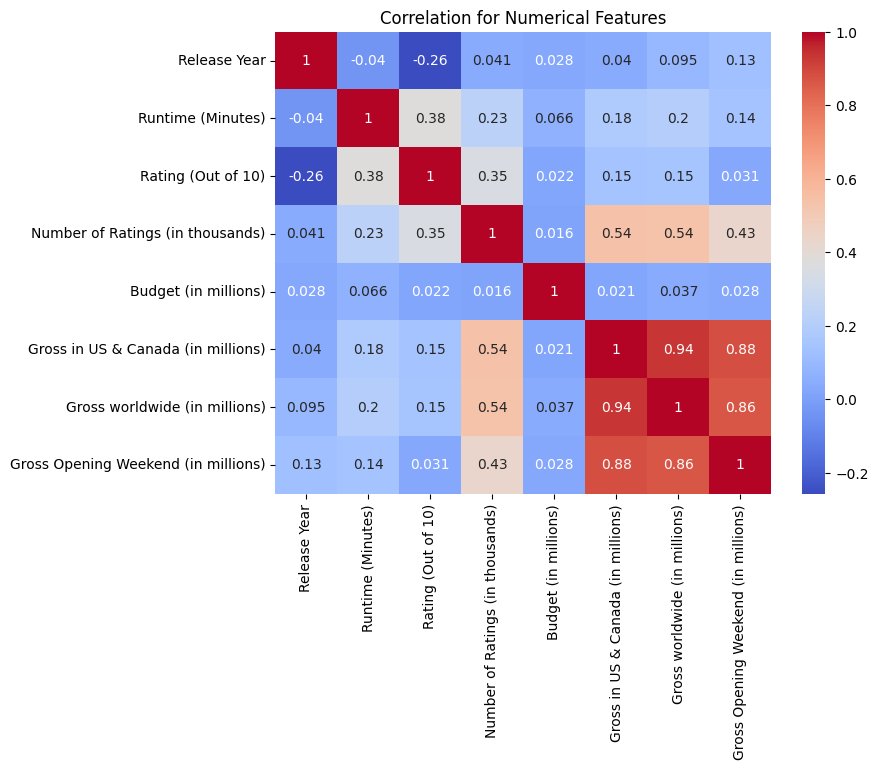

In [14]:
#correlation visualization
#want to see correlation for certain numerical features
# we can use this matrix to hypothesize/test relationships and % predictions.
heatmap_cols = ["Release Year","Runtime (Minutes)", "Rating (Out of 10)", "Number of Ratings (in thousands)", "Budget (in millions)", "Gross in US & Canada (in millions)", "Gross worldwide (in millions)", "Gross Opening Weekend (in millions)"]
movies_for_heatmap = movies[heatmap_cols]

fig, ax = plt.subplots(figsize = (8,6))
sns.heatmap(movies_for_heatmap.corr(numeric_only = True), cmap = "coolwarm", annot = True)
plt.title("Correlation for Numerical Features");

In [15]:
#Using Random Forest to predict the model
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
#dt.print(x.shape, y.shape)

**PART ONE**
We will be using a random forest regressor to help with our predictions. In the coding cell below, interaction features were added for predicting the worldwide gross without US & Canada gross or opening weekend gross. Having these interactions as features can help the model predict more accurately in this approach.

In [16]:
movies1 = movies
movies1["rating_budget_interaction"] = movies1["Rating (Out of 10)"]*movies1["Budget (in millions)"]
movies1["num_ratings_rate_interaction"] = movies1["Number of Ratings (in thousands)"]*movies1["Rating (Out of 10)"]
movies1["budget_numratings"] = movies1["Number of Ratings (in thousands)"]*movies1["Budget (in millions)"]
#defining the x and y of the model
target1 = 'Gross worldwide (in millions)'
drop_cols1 = ['Title', 'Summary', 'Director', 'Writer', 'Motion Picture Rating', 'Opening Weekend in US & Canada', "Gross in US & Canada (in millions)", "Gross Opening Weekend (in millions)"]
x1 = movies1.drop(columns=drop_cols1 + [target1])
y1 = movies1[target1]
y_log1 = np.log1p(y1)


In [17]:
#train/test split
from sklearn.model_selection import train_test_split
x_train1, x_test1, y_train1, y_test1 = train_test_split(x1, y_log1, test_size=0.2, random_state=42)
print('Train Shape:', x_train1.shape)
print('Test Shape:', x_test1.shape)

Train Shape: (5702, 58)
Test Shape: (1426, 58)


In [18]:
#Random Forest Portion
from sklearn.ensemble import RandomForestRegressor
random_forest1 = RandomForestRegressor( #feel free to change values to optimize.
    n_estimators = 58,
    max_depth = 14,
    min_samples_split = 2,
    min_samples_leaf = 4,
    random_state = 1,
    n_jobs = -1
)

random_forest1.fit(x_train1, y_train1)

RandomForestRegressor(max_depth=14, min_samples_leaf=4, n_estimators=58,
                      n_jobs=-1, random_state=1)

In [19]:
#Evaluating the Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

predictions1 = random_forest1.predict(x_test1)

print('MAE:', mean_absolute_error(y_test1, predictions1)) 
print('RMSE:', np.sqrt(mean_squared_error(y_test1, predictions1)))
print('R2 Score:', r2_score(y_test1, predictions1))

MAE: 0.7118862393538004
RMSE: 0.9446088398197009
R2 Score: 0.7534396107005965


Visualizations for our Global Gross Predictions

Once again, this was our main focus as it is more common in the real world with stakeholders. This approach focused on predicting the global gross with features like budget, runtime, interactions, ratings, and hot-encoded features. This is information that is typically used in the real world to predict how well a film will do in general.


In [20]:
x_test1["Predicted Worldwide Gross (in millions)"] = predictions1
y_testing1 = pd.DataFrame(y_test1)

The scatter plot below shows high correlation between the actual and predicted gross values for worldwide gross. 

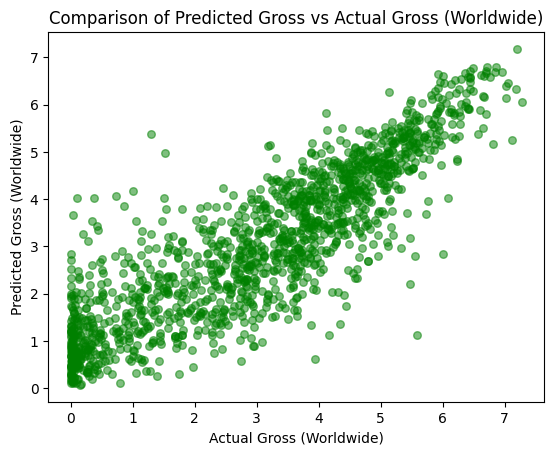

In [21]:
plt.scatter(y_test1, predictions1, alpha=0.5, s=30, color='green')
plt.title("Comparison of Predicted Gross vs Actual Gross (Worldwide)")
plt.xlabel("Actual Gross (Worldwide)")
plt.ylabel("Predicted Gross (Worldwide)");

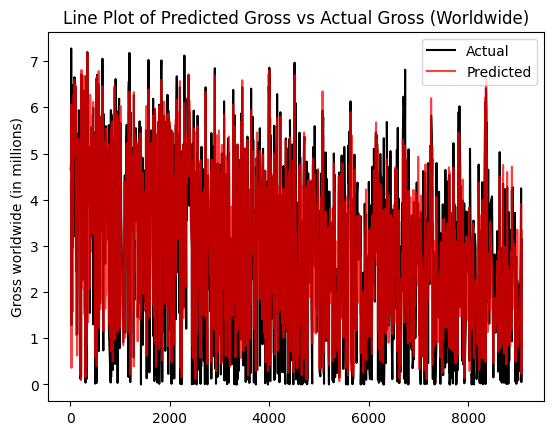

<Figure size 1500x600 with 0 Axes>

In [22]:
sns.lineplot(data = y_testing1, x=y_testing1.index, y= "Gross worldwide (in millions)", label='Actual', color='black', alpha= 1)
sns.lineplot(data = x_test1, x=x_test1.index, y="Predicted Worldwide Gross (in millions)", label = "Predicted", color='red', alpha = 0.75)
plt.legend()
plt.xlabel("")
plt.title("Line Plot of Predicted Gross vs Actual Gross (Worldwide)")
plt.figure(figsize=(15,6));
plt.show()

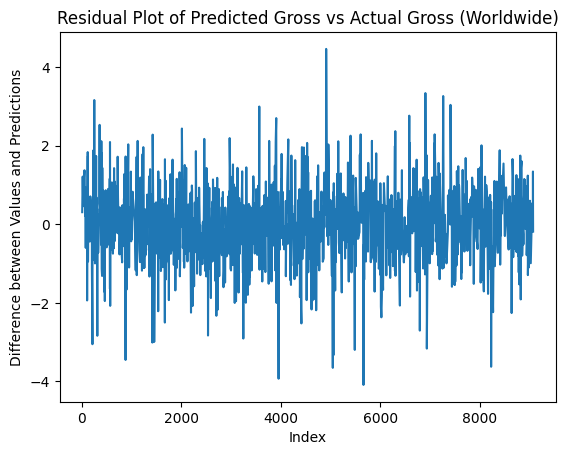

In [23]:
residuals1 = y_testing1["Gross worldwide (in millions)"] - x_test1["Predicted Worldwide Gross (in millions)"]
sns.lineplot(x=x_test1.index, y=residuals1)
plt.xlabel("Index")
plt.ylabel("Difference between Values and Predictions")
plt.title("Residual Plot of Predicted Gross vs Actual Gross (Worldwide)")
plt.show()
#randomness shows no bias, nor a tendency to over or under estimate. Centered around 0 with few outliers.

In [24]:
x_test_seasons1 = x_test1[["Predicted Worldwide Gross (in millions)", "Release Season"]]

def num_to_season1(m):
    if m == 1:
        return "Winter"
    elif m == 2:
        return "Spring"
    elif m == 3:
        return "Summer"
    else:
        return "Fall"

x_test_seasons1["Release Season"] = x_test_seasons1["Release Season"].apply(num_to_season1)

/tmp/ipykernel_1715/2445159565.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test_seasons1["Release Season"] = x_test_seasons1["Release Season"].apply(num_to_season1)


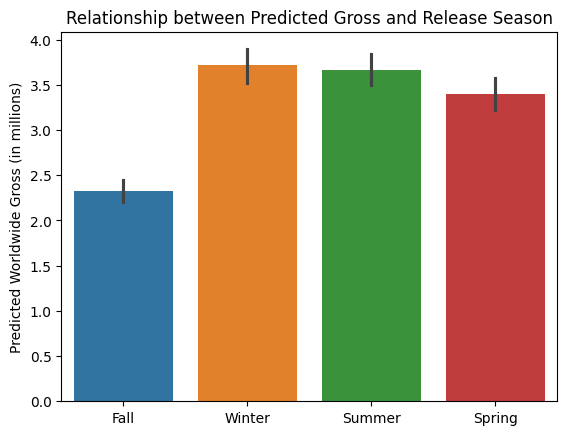

In [25]:
sns.barplot(data = x_test_seasons1, x="Release Season", y="Predicted Worldwide Gross (in millions)", hue="Release Season")
plt.xlabel("")
plt.title("Relationship between Predicted Gross and Release Season")
plt.show()

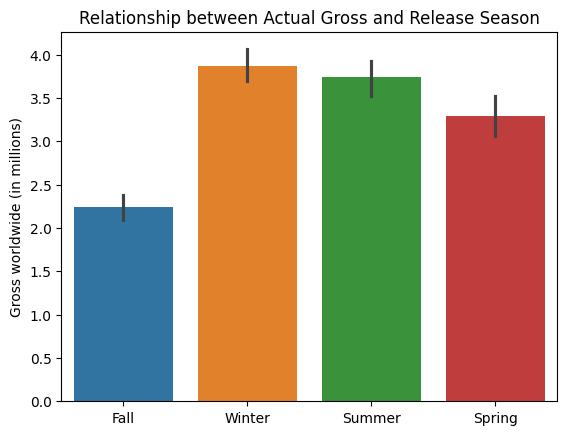

In [26]:
sns.barplot(data = y_testing1, x=x_test_seasons1["Release Season"], y= "Gross worldwide (in millions)", hue=x_test_seasons1["Release Season"])
plt.xlabel("")
plt.title("Relationship between Actual Gross and Release Season")
plt.show()

In [27]:
x_test_ratings1 = x_test1[["Predicted Worldwide Gross (in millions)", "MPAA_16+", "MPAA_18+", "MPAA_Approved", "MPAA_G", "MPAA_GP", "MPAA_M", "MPAA_M/PG", "MPAA_NC-17", "MPAA_Not Rated", "MPAA_PG", "MPAA_PG-13", "MPAA_Passed", "MPAA_R", "MPAA_TV-14", "MPAA_TV-G", "MPAA_TV-MA", "MPAA_TV-PG", "MPAA_Unrated", "MPAA_X"]]
x_test_ratings1["Ratings"] = x_test_ratings1[["MPAA_16+", "MPAA_18+", "MPAA_G", "MPAA_GP", "MPAA_M", "MPAA_M/PG", "MPAA_NC-17", "MPAA_PG", "MPAA_PG-13", "MPAA_R", "MPAA_TV-14", "MPAA_TV-G", "MPAA_TV-MA", "MPAA_TV-PG", "MPAA_Unrated", "MPAA_X"]].idxmax(axis=1).str.replace('MPAA_', '')
x_test_ratings1 = x_test_ratings1[["Predicted Worldwide Gross (in millions)", "Ratings"]]

/tmp/ipykernel_1715/4053921608.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test_ratings1["Ratings"] = x_test_ratings1[["MPAA_16+", "MPAA_18+", "MPAA_G", "MPAA_GP", "MPAA_M", "MPAA_M/PG", "MPAA_NC-17", "MPAA_PG", "MPAA_PG-13", "MPAA_R", "MPAA_TV-14", "MPAA_TV-G", "MPAA_TV-MA", "MPAA_TV-PG", "MPAA_Unrated", "MPAA_X"]].idxmax(axis=1).str.replace('MPAA_', '')


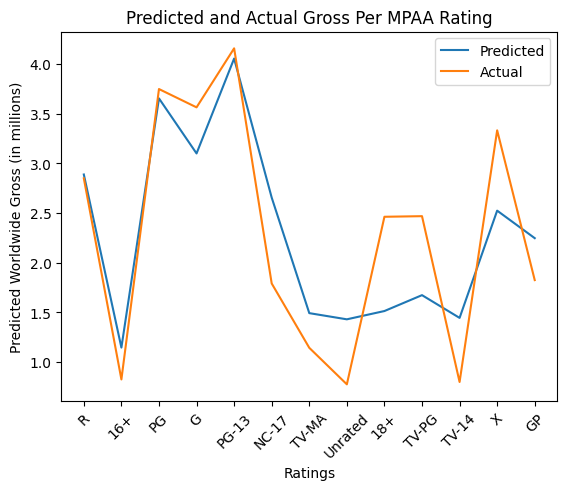

In [28]:
sns.lineplot(data=x_test_ratings1, x="Ratings", y="Predicted Worldwide Gross (in millions)", errorbar=None, label = "Predicted")
sns.lineplot(data=y_testing1, x=x_test_ratings1["Ratings"], y="Gross worldwide (in millions)", errorbar=None, label = "Actual")
plt.xticks(rotation=45)
plt.xlabel("Ratings")
plt.title("Predicted and Actual Gross Per MPAA Rating")
plt.legend()
plt.show()

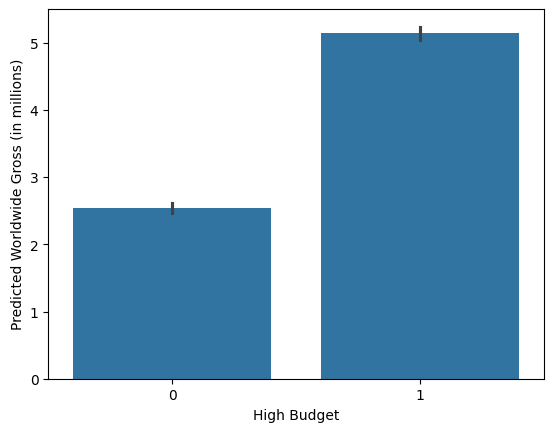

In [29]:
sns.barplot(data = x_test1, x="High Budget", y = "Predicted Worldwide Gross (in millions)");

In [30]:
# Drama, Comedy, Action, Adventure, Crime, Romance, Thriller, Horror, Mystery, Fantasy
x_test_genres1 = x_test1[["Predicted Worldwide Gross (in millions)", "Romance", "Fantasy", "Film-Noir", "Documentary", "Western", "Animation", "Musical", "Sport", "Action", "History", "Adventure", "Sci-Fi", "Biography", "Family", "War", "Horror", "Music", "Drama", "Comedy", "Thriller", "Mystery", "Crime"]]

# x_test_genres = x_test_genres.sum().sort_values(ascending = False)
# x_test_genres

#Romance, Fantasy, Film-Noir, Documentary, Western, Animation, Musical, 
#Sport, Action, History, Adventure, Sci-Fi, Biography, Family, War, Horror, 
#Music, Drama, Comedy, Thriller, Mystery, Crime        
x_test_genres1['Genres'] = x_test_genres1[["Drama", "Comedy", "Action", "Adventure", "Crime", "Romance", "Thriller", "Horror", "Mystery", "Fantasy"]].idxmax(axis=1)
x_test_genres1 = x_test_genres1[["Predicted Worldwide Gross (in millions)", "Genres"]]
x_test_genres1["index"] = x_test_genres1.index

/tmp/ipykernel_1715/1227320025.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test_genres1['Genres'] = x_test_genres1[["Drama", "Comedy", "Action", "Adventure", "Crime", "Romance", "Thriller", "Horror", "Mystery", "Fantasy"]].idxmax(axis=1)


In [31]:
y_testing1["index"] = y_testing1.index
y_testing_genres1 = pd.merge(y_testing1, x_test_genres1, left_on=y_testing1["index"], right_on = x_test_genres1["index"], how="inner")
y_testing_genres1["Diff"] = np.abs(y_testing_genres1["Predicted Worldwide Gross (in millions)"] - y_testing_genres1["Gross worldwide (in millions)"])
y_testing_genres1 = y_testing_genres1[["Diff", "Genres", "Predicted Worldwide Gross (in millions)", "Gross worldwide (in millions)"]]

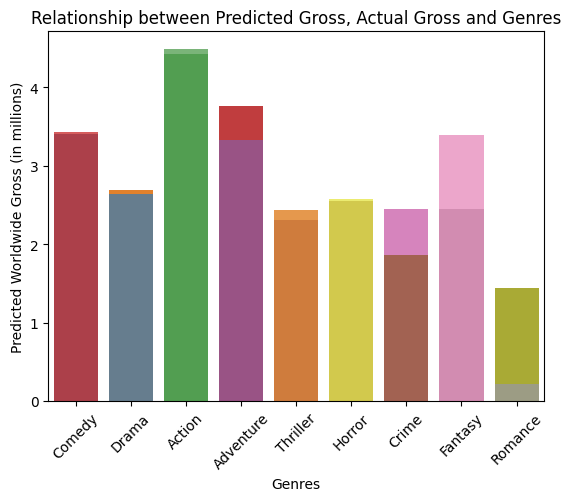

In [32]:
sns.barplot(data=y_testing_genres1, x="Genres", y="Predicted Worldwide Gross (in millions)", errorbar = None, hue = "Genres")
sns.barplot(data = y_testing1, x=x_test_genres1["Genres"], y= "Gross worldwide (in millions)", hue=x_test_genres1["Genres"], errorbar = None, palette="Set1", alpha = 0.8)
plt.xticks(rotation=45)
plt.title("Relationship between Predicted Gross, Actual Gross and Genres")
plt.xlabel("Genres")
plt.show();
# #Actual gross is the lighter one

**PART TWO**
Predicting Worldwide Gross when given US & Canada and Opening Weekend Gross. Some films are released globally later on, and this can come in handy when this is the situation. Sometime investors are given the opportunity to invest after a smaller release, to help boost sales.

In [33]:
#defining the x and y of the model
target = 'Gross worldwide (in millions)'
drop_cols = ['Title', 'Summary', 'Director', 'Writer', 'Motion Picture Rating', 'Opening Weekend in US & Canada']
x = movies.drop(columns=drop_cols + [target])
y = movies[target]
y_log = np.log1p(y)

In [34]:
#train/test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y_log, test_size=0.2, random_state=42)
print('Train Shape:', x_train.shape) 
print('Test Shape:', x_test.shape)

Train Shape: (5702, 60)
Test Shape: (1426, 60)


In [35]:
#seeing how many unknown values here 
(movies["Opening Weekend in US & Canada"] == "unknown").sum()

1442

In [36]:
#Random Forest Portion
from sklearn.ensemble import RandomForestRegressor
random_forest = RandomForestRegressor( #feel free to change values to optimize.
    n_estimators = 74,
    max_depth = 18,
    min_samples_split = 6,
    min_samples_leaf = 4,
    random_state = 1,
    n_jobs = -1
)

random_forest.fit(x_train, y_train)

RandomForestRegressor(max_depth=18, min_samples_leaf=4, min_samples_split=6,
                      n_estimators=74, n_jobs=-1, random_state=1)

In [37]:
#Evaluating the Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

predictions = random_forest.predict(x_test)

print('MAE:', mean_absolute_error(y_test, predictions)) 
print('RMSE:', np.sqrt(mean_squared_error(y_test, predictions)))
print('R2 Score:', r2_score(y_test, predictions))

MAE: 0.330045173877414
RMSE: 0.5176125317403326
R2 Score: 0.9259664012443372


MAE: How much money it is off by \(in Millions, usually ranging from $5 million to $1 Billion\)

\-Pre Log: 21\.545

\-Post Log: 0\.333

RMSE: This model struggles slightly with outliers \(ex: Avatar, Barbie, Avengers, etc\.\)

\-Pre Log: 47\.607

\-Post Log: 0\.519

R2: How well the model can predict a movie's global revenue

\-Pre Log: 0\.913

\-Post Log: 0\.926

In [38]:
x_test["Predicted Worldwide Gross (in millions)"] = predictions


In [39]:
y_testing = pd.DataFrame(y_test)

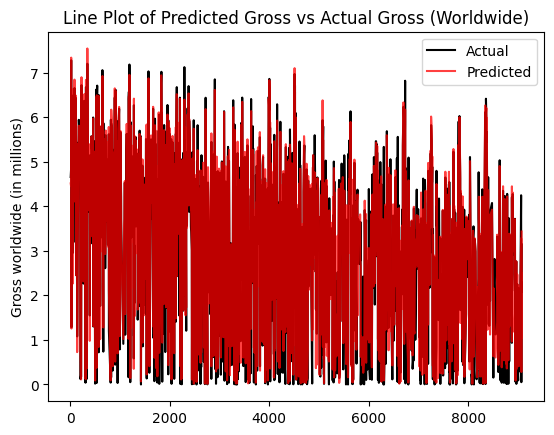

<Figure size 1500x600 with 0 Axes>

In [40]:
sns.lineplot(data = y_testing, x=y_testing.index, y= "Gross worldwide (in millions)", label='Actual', color='black', alpha= 1)
sns.lineplot(data = x_test, x=x_test.index, y="Predicted Worldwide Gross (in millions)", label = "Predicted", color='red', alpha = 0.75)
plt.legend()
plt.xlabel("")
plt.title("Line Plot of Predicted Gross vs Actual Gross (Worldwide)")
plt.figure(figsize=(15,6))
plt.show();

In [41]:
x_test.head()
#Movies are release in US before globally, meaning that can also influence our worlwide gross

,Release Year,Runtime (Minutes),Rating (Out of 10),Number of Ratings (in thousands),Budget (in millions),Gross in US & Canada (in millions),Gross Opening Weekend (in millions),High Budget,High Rating,History,...,MPAA_TV-G,MPAA_TV-MA,MPAA_TV-PG,MPAA_Unrated,MPAA_X,MPAA_unknown,rating_budget_interaction,num_ratings_rate_interaction,budget_numratings,Predicted Worldwide Gross (in millions)
2687,2022.0,98.0,6.5,17.0,20.0,0.539,0.267,0,0,0,...,0,0,0,0,0,0,130.0,110.5,340.0,0.832064
3577,1946.0,102.0,7.9,106.0,2.0,23.511,5.312,0,1,0,...,0,0,0,0,0,0,15.8,837.4,212.0,0.025051
7196,2021.0,136.0,6.5,11.0,21.0,0.053,0.007,0,0,0,...,0,0,0,0,0,0,136.5,71.5,231.0,1.344295
8736,2009.0,119.0,6.3,20.0,21.0,0.025,0.006,0,0,0,...,0,0,0,0,0,0,132.3,126.0,420.0,0.797317
2207,2021.0,107.0,6.2,37.0,21.0,5.213,2.316,0,0,0,...,0,0,0,0,0,0,130.2,229.4,777.0,2.488299


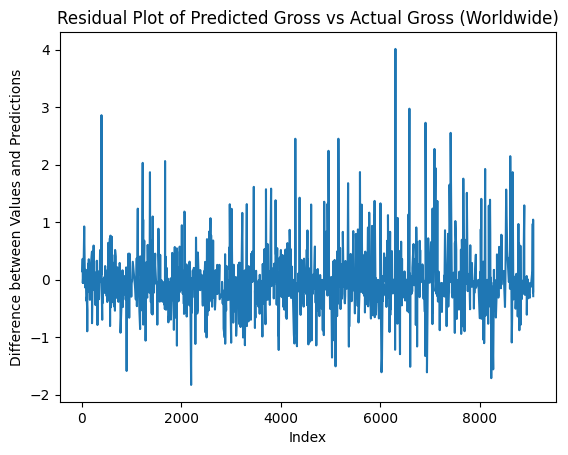

In [42]:
residuals = y_testing["Gross worldwide (in millions)"] - x_test["Predicted Worldwide Gross (in millions)"]
sns.lineplot(x=x_test.index, y=residuals)
plt.xlabel("Index")
plt.ylabel("Difference between Values and Predictions")
plt.title("Residual Plot of Predicted Gross vs Actual Gross (Worldwide)")
plt.show()
#randomness shows no bias, nor a tendency to over or under estimate. Centered around 0 with few outliers.

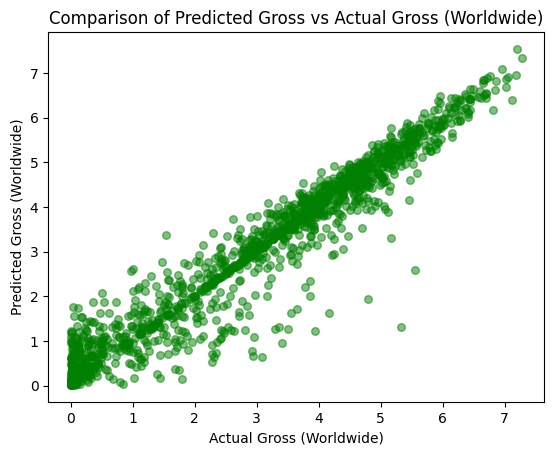

In [43]:
plt.scatter(y_test, predictions, alpha=0.5, s=30, color='green')
plt.title("Comparison of Predicted Gross vs Actual Gross (Worldwide)")
plt.xlabel("Actual Gross (Worldwide)")
plt.ylabel("Predicted Gross (Worldwide)");
#there seems to be high correlation, as the scatter points are in similar shape to a perfect line

In [44]:
x_test_seasons = x_test[["Predicted Worldwide Gross (in millions)", "Release Season"]]

def num_to_season(m):
    if m == 1:
        return "Winter"
    elif m == 2:
        return "Spring"
    elif m == 3:
        return "Summer"
    else:
        return "Fall"

x_test_seasons["Release Season"] = x_test_seasons["Release Season"].apply(num_to_season)

/tmp/ipykernel_1715/4140698979.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test_seasons["Release Season"] = x_test_seasons["Release Season"].apply(num_to_season)


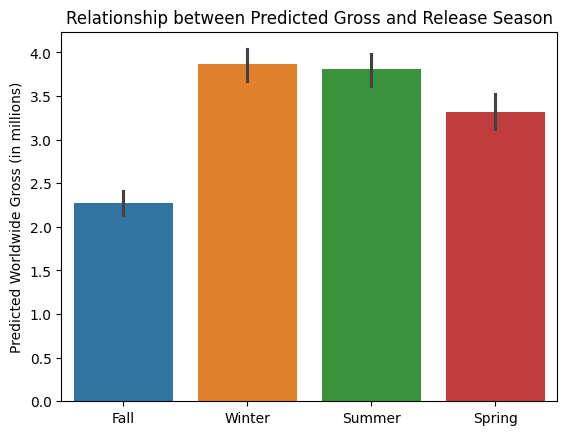

In [45]:
sns.barplot(data = x_test_seasons, x="Release Season", y="Predicted Worldwide Gross (in millions)", hue="Release Season")
plt.xlabel("")
plt.title("Relationship between Predicted Gross and Release Season")
plt.show()

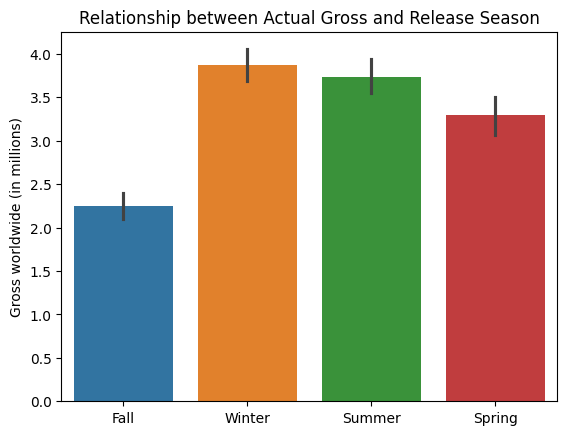

In [46]:
sns.barplot(data = y_testing, x=x_test_seasons["Release Season"], y= "Gross worldwide (in millions)", hue=x_test_seasons["Release Season"])
plt.xlabel("")
plt.title("Relationship between Actual Gross and Release Season")
plt.show()

In [47]:
# Drama, Comedy, Action, Adventure, Crime, Romance, Thriller, Horror, Mystery, Fantasy
x_test_genres = x_test[["Predicted Worldwide Gross (in millions)", "Romance", "Fantasy", "Film-Noir", "Documentary", "Western", "Animation", "Musical", "Sport", "Action", "History", "Adventure", "Sci-Fi", "Biography", "Family", "War", "Horror", "Music", "Drama", "Comedy", "Thriller", "Mystery", "Crime"]]

# x_test_genres = x_test_genres.sum().sort_values(ascending = False)
# x_test_genres

#Romance, Fantasy, Film-Noir, Documentary, Western, Animation, Musical, 
#Sport, Action, History, Adventure, Sci-Fi, Biography, Family, War, Horror, 
#Music, Drama, Comedy, Thriller, Mystery, Crime        
x_test_genres['Genres'] = x_test_genres[["Drama", "Comedy", "Action", "Adventure", "Crime", "Romance", "Thriller", "Horror", "Mystery", "Fantasy"]].idxmax(axis=1)
x_test_genres = x_test_genres[["Predicted Worldwide Gross (in millions)", "Genres"]]
x_test_genres["index"] = x_test_genres.index

/tmp/ipykernel_1715/2938097804.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test_genres['Genres'] = x_test_genres[["Drama", "Comedy", "Action", "Adventure", "Crime", "Romance", "Thriller", "Horror", "Mystery", "Fantasy"]].idxmax(axis=1)


In [48]:
y_testing["index"] = y_testing.index
y_testing_genres = pd.merge(y_testing, x_test_genres, left_on=y_testing["index"], right_on = x_test_genres["index"], how="inner")
y_testing_genres["Diff"] = np.abs(y_testing_genres["Predicted Worldwide Gross (in millions)"] - y_testing_genres["Gross worldwide (in millions)"])
y_testing_genres = y_testing_genres[["Diff", "Genres", "Predicted Worldwide Gross (in millions)", "Gross worldwide (in millions)"]]

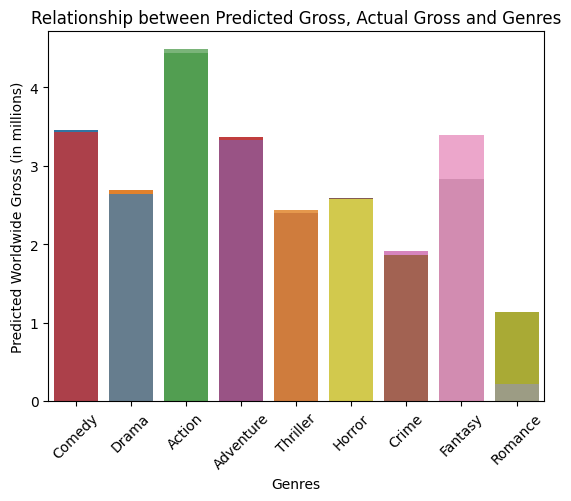

In [49]:
sns.barplot(data=y_testing_genres, x="Genres", y="Predicted Worldwide Gross (in millions)", errorbar = None, hue = "Genres")
sns.barplot(data = y_testing, x=x_test_genres["Genres"], y= "Gross worldwide (in millions)", hue=x_test_genres["Genres"], errorbar = None, palette="Set1", alpha = 0.8)
plt.xticks(rotation=45)
plt.title("Relationship between Predicted Gross, Actual Gross and Genres")
plt.xlabel("Genres")
plt.show();
# #Actual gross is the lighter one

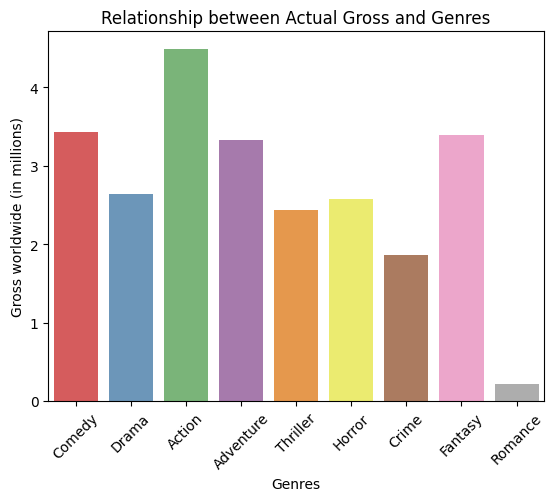

In [50]:
sns.barplot(data = y_testing, x=x_test_genres["Genres"], y= "Gross worldwide (in millions)", hue=x_test_genres["Genres"], errorbar = None, palette="Set1", alpha = 0.8)
plt.xticks(rotation=45)
plt.title("Relationship between Actual Gross and Genres")
plt.xlabel("Genres")
plt.show();

In [51]:
x_test_ratings = x_test[["Predicted Worldwide Gross (in millions)", "MPAA_16+", "MPAA_18+", "MPAA_Approved", "MPAA_G", "MPAA_GP", "MPAA_M", "MPAA_M/PG", "MPAA_NC-17", "MPAA_Not Rated", "MPAA_PG", "MPAA_PG-13", "MPAA_Passed", "MPAA_R", "MPAA_TV-14", "MPAA_TV-G", "MPAA_TV-MA", "MPAA_TV-PG", "MPAA_Unrated", "MPAA_X"]]
x_test_ratings["Ratings"] = x_test_ratings[["MPAA_16+", "MPAA_18+", "MPAA_G", "MPAA_GP", "MPAA_M", "MPAA_M/PG", "MPAA_NC-17", "MPAA_PG", "MPAA_PG-13", "MPAA_R", "MPAA_TV-14", "MPAA_TV-G", "MPAA_TV-MA", "MPAA_TV-PG", "MPAA_Unrated", "MPAA_X"]].idxmax(axis=1).str.replace('MPAA_', '')
x_test_ratings = x_test_ratings[["Predicted Worldwide Gross (in millions)", "Ratings"]]

/tmp/ipykernel_1715/4143581677.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test_ratings["Ratings"] = x_test_ratings[["MPAA_16+", "MPAA_18+", "MPAA_G", "MPAA_GP", "MPAA_M", "MPAA_M/PG", "MPAA_NC-17", "MPAA_PG", "MPAA_PG-13", "MPAA_R", "MPAA_TV-14", "MPAA_TV-G", "MPAA_TV-MA", "MPAA_TV-PG", "MPAA_Unrated", "MPAA_X"]].idxmax(axis=1).str.replace('MPAA_', '')


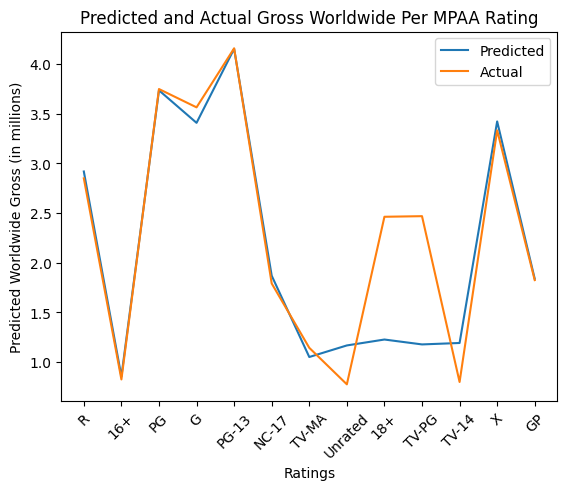

In [52]:
sns.lineplot(data=x_test_ratings, x="Ratings", y="Predicted Worldwide Gross (in millions)", errorbar=None, label = "Predicted")
sns.lineplot(data=y_testing, x=x_test_ratings["Ratings"], y="Gross worldwide (in millions)", errorbar=None, label = "Actual")
plt.xticks(rotation=45)
plt.xlabel("Ratings")
plt.title("Predicted and Actual Gross Worldwide Per MPAA Rating")
plt.legend()
plt.show()

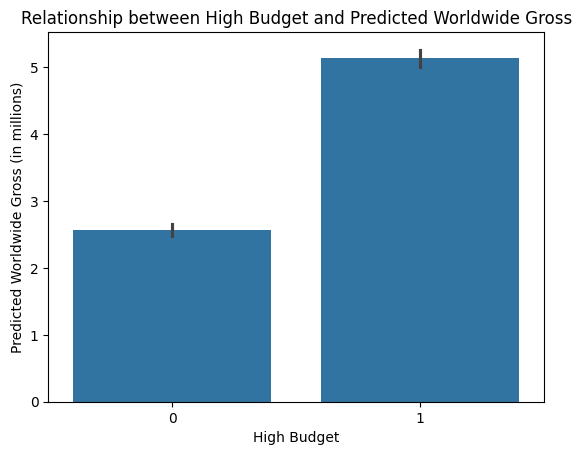

In [53]:
sns.barplot(data = x_test, x="High Budget", y = "Predicted Worldwide Gross (in millions)")
plt.title("Relationship between High Budget and Predicted Worldwide Gross");

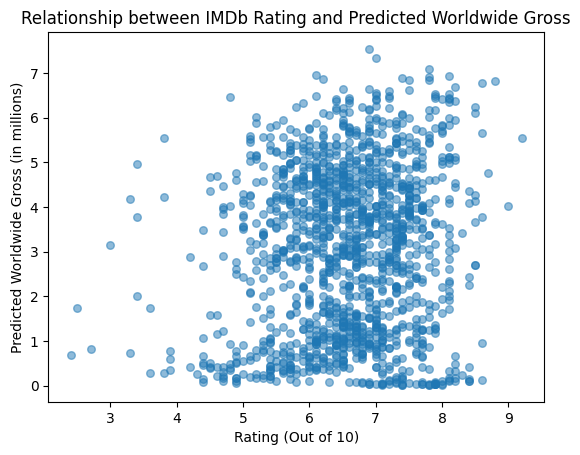

In [54]:
plt.scatter(data = x_test, x="Rating (Out of 10)", y = "Predicted Worldwide Gross (in millions)", alpha = 0.5, s = 30);
plt.ylabel("Predicted Worldwide Gross (in millions)")
plt.xlabel("Rating (Out of 10)")
plt.title("Relationship between IMDb Rating and Predicted Worldwide Gross")
plt.show();

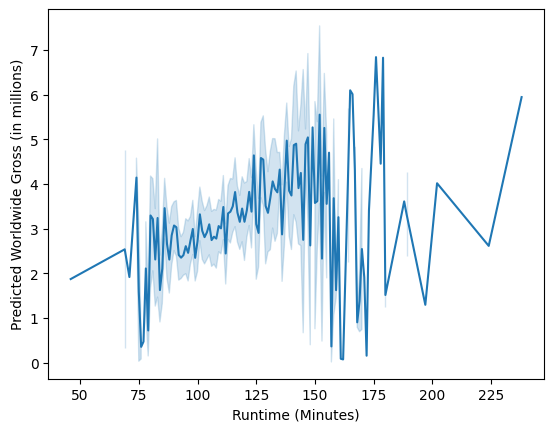

In [55]:
sns.lineplot(data = x_test, x = "Runtime (Minutes)", y ="Predicted Worldwide Gross (in millions)");

In [56]:
#code for hyperparameter tuning if needed later
#rom sklearn.model_selection import RandomizedSearchCV
#from scipy.stats import randint
#params = {"n_estimators": randint(50, 200),"max_depth": randint(1, 20), "min_samples_leaf": randint(1, 20), "min_samples_split": randint(2, 20)}
#rf = RandomForestRegressor(random_state = 1)
#search = RandomizedSearchCV(rf, param_distributions = params, n_iter = 50, cv = 3, scoring = "neg_mean_absolute_error", random_state = 1)
#search.fit(x, y)
#print(search.best_params_, search.best_score_)


In [57]:
# take 1: {'max_depth': 18, 'min_samples_leaf': 4, 'min_samples_split': 6, 'n_estimators': 74} -22.272746420364196

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=d33b8416-8833-4dfe-af53-b966405ea9b0' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>